In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [3]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [4]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


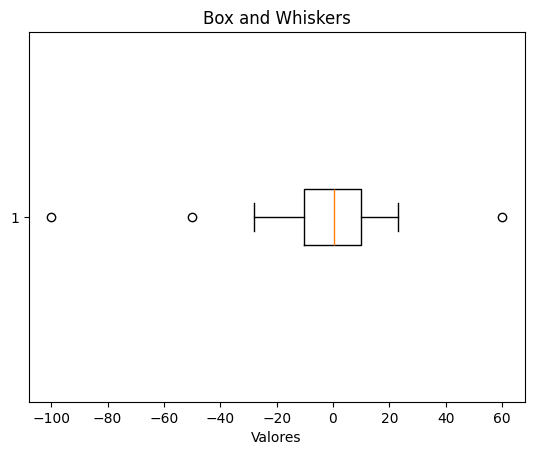

In [ ]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X, vert=False)
plt.title('Box and Whiskers')
plt.xlabel('Valores')
plt.show()

In [ ]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2) # rango de dispersión, si es muy grande, los datos están muy dispersos

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [12]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
#pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?

curtosis = stats.kurtosis(X[:,2]) # Curtosis de la variable "longitud del pétalo"
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?

curtosis = stats.kurtosis(X[:,1]) # Curtosis de la variable "ancho del sépalo"
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')


Curtosis  -1.3955
Distribución Platicúrtica
Curtosis  0.181
Distribución Leptocúrtica


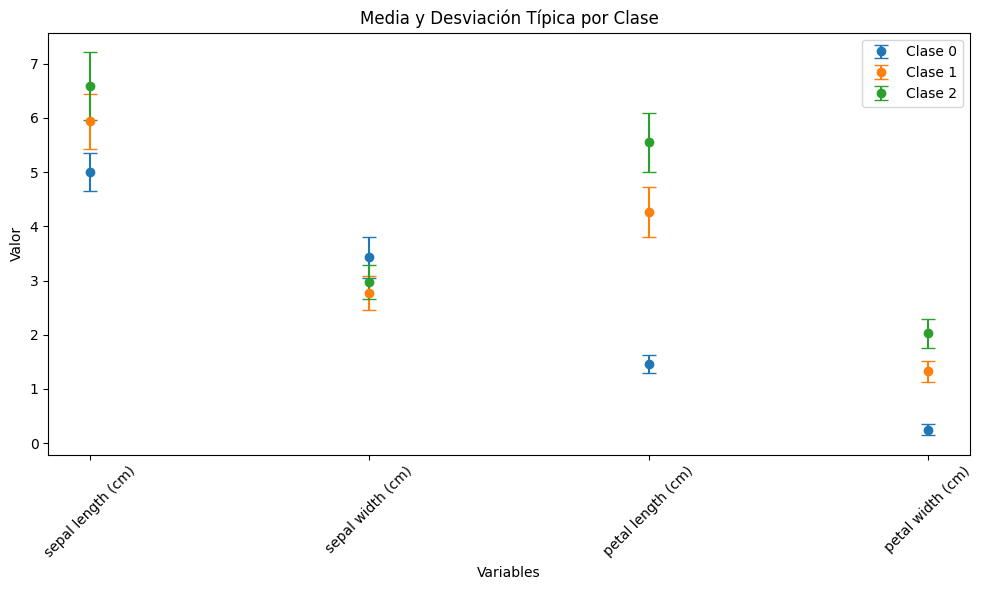

In [15]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
plt.figure(figsize=(10, 6))
for i in range(3):  # Para cada clase
    class_data = X[y == i]  # Datos de la clase i
    mean = np.mean(class_data, axis=0)  # Media
    std_dev = np.std(class_data, axis=0)  # Desviación típica
    plt.errorbar(range(class_data.shape[1]), mean, yerr=std_dev, label=f'Clase {i}', fmt='o', capsize=5)
plt.title('Media y Desviación Típica por Clase')
plt.xlabel('Variables')
plt.ylabel('Valor')
plt.xticks(range(X.shape[1]), iris.feature_names, rotation=45)
plt.legend()
plt.tight_layout()

El resultado debería ser algo como esto:
<img src="images/errorbar.png">